In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
#Cargamos el dataset
df = pd.read_csv("healthcheck_colombia.csv")

In [6]:
filas, columnas = df.shape
print(f"El dataset tiene {filas} filas y {columnas} columnas")

El dataset tiene 350 filas y 13 columnas


In [7]:
df.head(8)

,id_trabajador,edad,ciudad,cargo,sector,nivel,anios_experiencia,horas_semana,salario_cop,nivel_estres,dias_ausencia_anio,satisfaccion_laboral,fecha_ingreso
0,1001,28,Bogotá,QA Engineer,Fintech,Junior,1,48.0,10859922.0,2.0,10.0,6.0,01/01/2018
1,1002,41,Barranquilla,UX Designer,Consultoría,Junior,9,56.0,6190583.0,8.0,6.0,8.0,04/01/2018
2,1003,50,Barranquilla,Desarrollador Junior,E-commerce,Lead,11,50.0,4099908.0,6.0,4.0,6.0,07/01/2018
3,1004,36,Bogotá,UX Designer,Healthtech,Senior,16,46.0,4664412.0,4.0,16.0,9.0,10/01/2018
4,1005,32,Medellín,Desarrollador Junior,Healthtech,Mid,7,53.0,7809792.0,5.0,19.0,9.0,13/01/2018
5,1006,29,Bogotá,Data Analyst,Edtech,Mid,10,58.0,4853847.0,8.0,8.0,2.0,16/01/2018
6,1007,50,Barranquilla,QA Engineer,Edtech,Mid,2,43.0,5392478.0,3.0,13.0,10.0,19/01/2018
7,1008,42,Bucaramanga,DevOps,Consultoría,Junior,5,45.0,NaN,NaN,11.0,1.0,22/01/2018


In [8]:
df.tail(5)

,id_trabajador,edad,ciudad,cargo,sector,nivel,anios_experiencia,horas_semana,salario_cop,nivel_estres,dias_ausencia_anio,satisfaccion_laboral,fecha_ingreso
345,1346,28,Medellín,UX Designer,Consultoría,Mid,6,41.0,4260462.0,3.0,10.0,5.0,01/11/2020
346,1347,49,Barranquilla,Desarrollador Junior,Fintech,Junior,17,54.0,6558848.0,5.0,0.0,2.0,04/11/2020
347,1348,37,Medellín,DevOps,Healthtech,Mid,2,59.0,3309178.0,2.0,16.0,7.0,07/11/2020
348,1349,47,Barranquilla,Data Analyst,E-commerce,Mid,9,57.0,10432310.0,NaN,14.0,4.0,10/11/2020
349,1350,37,Barranquilla,Desarrollador Senior,Consultoría,Senior,6,54.0,7277402.0,6.0,19.0,1.0,13/11/2020


In [9]:
#Tipos de datos por columna
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id_trabajador         350 non-null    int64  
 1   edad                  350 non-null    int64  
 2   ciudad                335 non-null    str    
 3   cargo                 350 non-null    str    
 4   sector                350 non-null    str    
 5   nivel                 350 non-null    str    
 6   anios_experiencia     350 non-null    int64  
 7   horas_semana          350 non-null    float64
 8   salario_cop           315 non-null    float64
 9   nivel_estres          322 non-null    float64
 10  dias_ausencia_anio    350 non-null    float64
 11  satisfaccion_laboral  328 non-null    float64
 12  fecha_ingreso         350 non-null    str    
dtypes: float64(5), int64(3), str(5)
memory usage: 51.5 KB


In [ ]:
#Datos estadístico con transposición
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
id_trabajador,350.0,1175.50,101.18,1001.0,1088.25,1175.5,1262.75,1350.0
edad,350.0,36.94,9.23,22.0,29.00,37.0,45.75,51.0
anios_experiencia,350.0,8.71,5.70,0.0,4.00,9.0,13.00,54.0
horas_semana,350.0,49.52,6.39,40.0,44.00,49.0,54.75,97.0
salario_cop,315.0,7477138.52,5613607.86,2519675.0,5008809.00,7198713.0,9496370.00,95000000.0
nivel_estres,322.0,5.26,2.85,0.0,3.00,5.0,8.00,10.0
dias_ausencia_anio,350.0,9.99,11.02,0.0,5.00,10.0,14.00,187.0
satisfaccion_laboral,328.0,5.35,2.88,1.0,3.00,5.0,8.00,10.0


In [ ]:
#Datos estadísticos de las v. categóricas
df.describe(include='object')

C:\Users\JORGE\AppData\Local\Temp\ipykernel_5728\87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,ciudad,cargo,sector,nivel,fecha_ingreso
count,335,350,350,350,350
unique,5,7,5,4,350
top,Bucaramanga,Desarrollador Junior,Fintech,Junior,01/01/2018
freq,73,57,74,121,1


In [16]:
categoricas = df.select_dtypes(include="object").columns.tolist()

C:\Users\JORGE\AppData\Local\Temp\ipykernel_5728\3193039719.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categoricas = df.select_dtypes(include="object").columns.tolist()


In [17]:
#Exploración de variables categóricas
for col in categoricas:
    if col != 'fecha_ingreso':
        print(f"\n Columna: {col}")
        print(df[col].value_counts())
        print(f"  --> Valores únicos: {df[col].nunique()}")


 Columna: ciudad
ciudad
Bucaramanga     73
Barranquilla    70
Medellín        69
Bogotá          66
Cali            57
Name: count, dtype: int64
  --> Valores únicos: 5

 Columna: cargo
cargo
Desarrollador Junior    57
QA Engineer             55
Desarrollador Senior    52
UX Designer             50
Product Manager         48
Data Analyst            46
DevOps                  42
Name: count, dtype: int64
  --> Valores únicos: 7

 Columna: sector
sector
Fintech        74
Edtech         73
Consultoría    72
Healthtech     66
E-commerce     65
Name: count, dtype: int64
  --> Valores únicos: 5

 Columna: nivel
nivel
Junior    121
Mid       119
Senior     73
Lead       37
Name: count, dtype: int64
  --> Valores únicos: 4


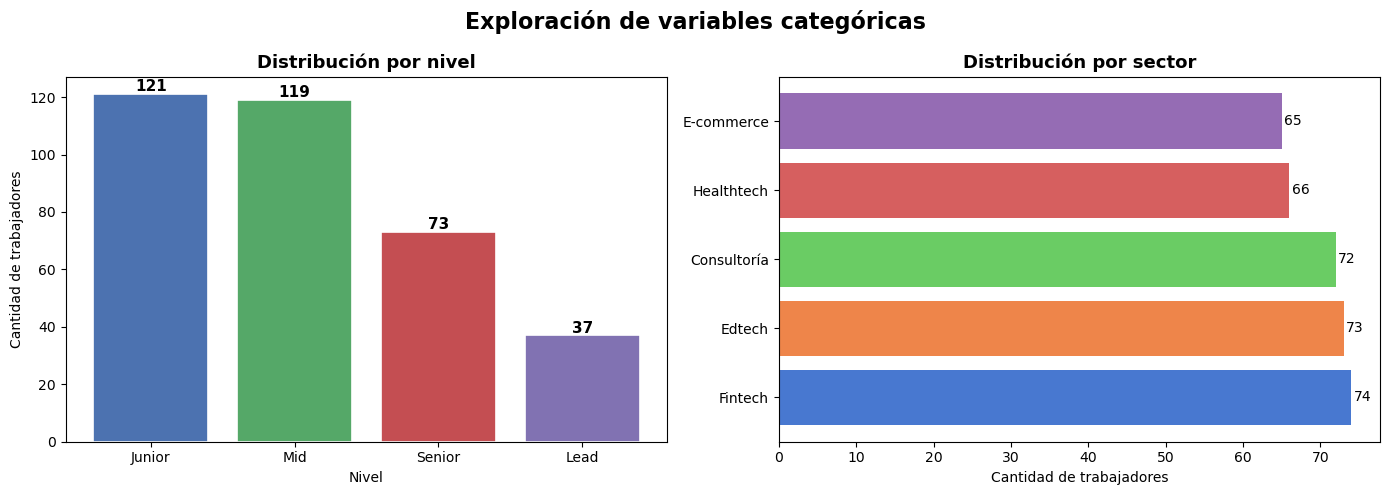

In [28]:
#Visualizacion: distribución de los trabajadores por nivel y sector
#fig: Es el lienzo, axes: subgraficas dentro de la hoja
fig, axes = plt.subplots(1, 2, figsize=(14,5))

#Grafica 1: Nivel de trabajadores
orden_nivel = ['Junior', 'Mid', 'Senior', "Lead"]
conteo_nivel = df['nivel'].value_counts().reindex(orden_nivel)

axes[0].bar(
    conteo_nivel.index, #Eje x categorias
    conteo_nivel.values, #Eje y cantidad de cada categoria
    color=['#4C72B0', '#55A868', '#C44E52', '#8172B2'],
    edgecolor='white', #Borde blanco entre barras
    linewidth=1.2
)

axes[0].set_title("Distribución por nivel", fontsize=13, fontweight='bold')
axes[0].set_xlabel('Nivel')
axes[0].set_ylabel("Cantidad de trabajadores")

#Añadir numero a cada barra
for i, v in enumerate(conteo_nivel.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontsize=11, fontweight='bold')


#Segunda Gráfica
conteo_sector = df['sector'].value_counts()

axes[1].barh(
    conteo_sector.index,
    conteo_sector.values,
    color=sns.color_palette('muted', len(conteo_sector))
)

axes[1].set_title("Distribución por sector", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Cantidad de trabajadores")

for i, v in enumerate(conteo_sector.values):
    axes[1].text(v + 0.3, i, str(v), va='center', fontsize=10)

plt.suptitle("Exploración de variables categóricas", fontsize=16, fontweight='bold')

plt.tight_layout() #Ajustar de forma autmática el espaciado para que nada se ejecute como error
plt.show()








plt.show()

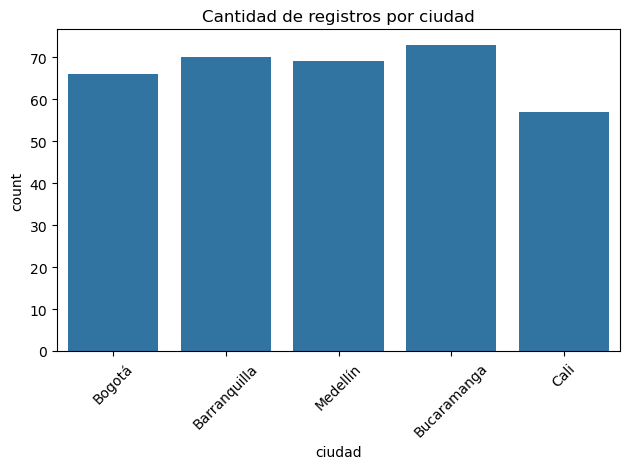

In [31]:
#Gráfica barras: Frecuencia de una columna categórica

sns.countplot(data=df, x="ciudad")
plt.title("Cantidad de registros por ciudad")
plt.xticks(rotation=45)
plt.tight_layout() #Ajustar de forma autmática el espaciado para que nada se ejecute como error
plt.show()
